# **Day 33: Decision Trees**
*Module 5 - Classification*

A decision tree asks a sequence of yes/no questions ("Is NDVI > 0.4?"). Trees are interpretable, need no scaling, handle mixed feature types and non-linear interactions, and are the **building block of Random Forests and gradient boosting** (the strongest models for tabular data).

> A decision tree asks a series of yes/no questions about the features until it reaches an answer. It is easy to read and needs little preprocessing, but a deep tree memorises noise.
>
> *Example:* "Is NDVI > 0.4? If yes, is slope > 15 degrees? Then forest, otherwise cropland." That is a tiny decision tree.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import cross_val_score, train_test_split
rng = np.random.default_rng(33)

## **1. A First Tree**
Land-cover from 3 features: NDVI, NDWI and brightness.

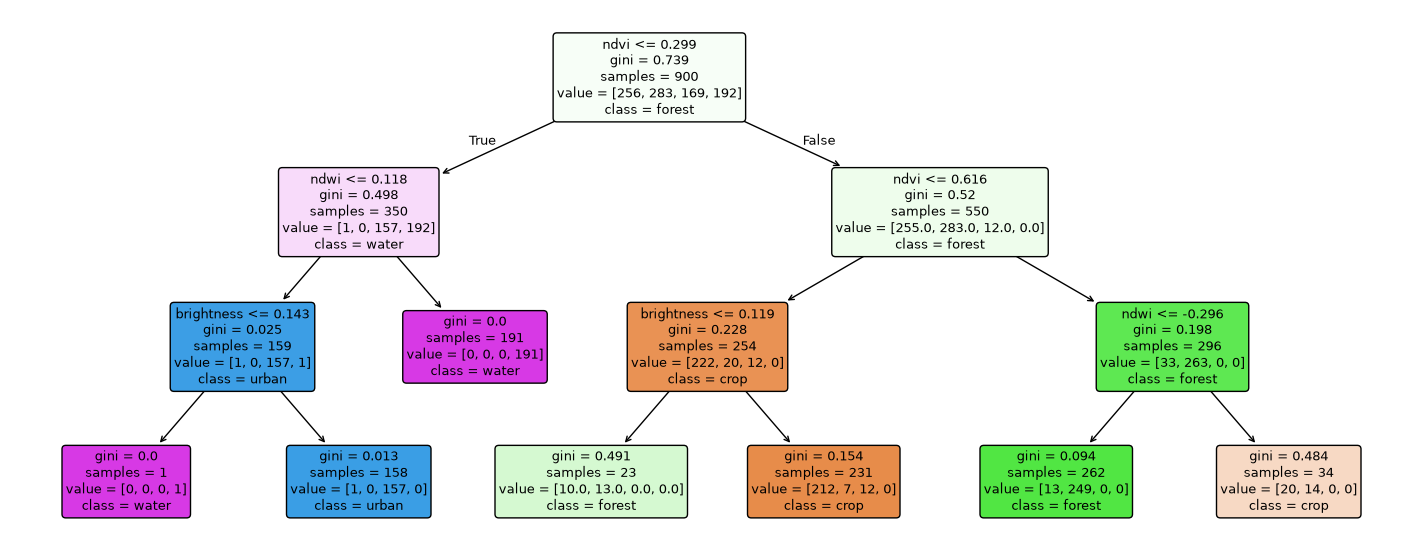

|--- ndvi <= 0.30
|   |--- ndwi <= 0.12
|   |   |--- brightness <= 0.14
|   |   |   |--- class: water
|   |   |--- brightness >  0.14
|   |   |   |--- class: urban
|   |--- ndwi >  0.12
|   |   |--- class: water
|--- ndvi >  0.30
|   |--- ndvi <= 0.62
|   |   |--- brightness <= 0.12
|   |   |   |--- class: forest
|   |   |--- brightness >  0.12
|   |   |   |--- class: crop
|   |--- ndvi >  0.62
|   |   |--- ndwi <= -0.30
|   |   |   |--- class: forest
|   |   |--- ndwi >  -0.30
|   |   |   |--- class: crop



In [2]:
n = 900
cls = rng.choice(["water", "forest", "crop", "urban"], n, p=[0.2, 0.3, 0.3, 0.2])
params = {"water": (-0.1, 0.35, 0.08), "forest": (0.75, -0.45, 0.12), "crop": (0.5, -0.3, 0.2), "urban": (0.15, -0.15, 0.3)}
df = pd.DataFrame([{"ndvi": rng.normal(p_[0], 0.1), "ndwi": rng.normal(p_[1], 0.1), "brightness": rng.normal(p_[2], 0.05), "cls": c}
                   for c in cls for p_ in [params[c]]])
X, y = df[["ndvi", "ndwi", "brightness"]], df.cls
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, y)
plt.figure(figsize=(18, 7)); plot_tree(tree, feature_names=X.columns, class_names=tree.classes_, filled=True, rounded=True, fontsize=9); plt.show()
print(export_text(tree, feature_names=list(X.columns)))

Each internal node tests one feature against a threshold; each leaf predicts the majority class of its training samples (and class proportions as probabilities).

## **2. Split Criteria**
At each node the algorithm tries every feature and every threshold, and picks the split that makes the children **purest**.

| Criterion | Formula | Note |
|---|---|---|
| Gini impurity | $1 - \sum_k p_k^2$ | Default in sklearn; fast |
| Entropy | $-\sum_k p_k\log_2 p_k$ | Information gain (Day 12) |
| MSE (regression) | variance of $y$ in the node | Leaf predicts the mean |

Quality of a split = parent impurity minus the **weighted** impurity of the children.

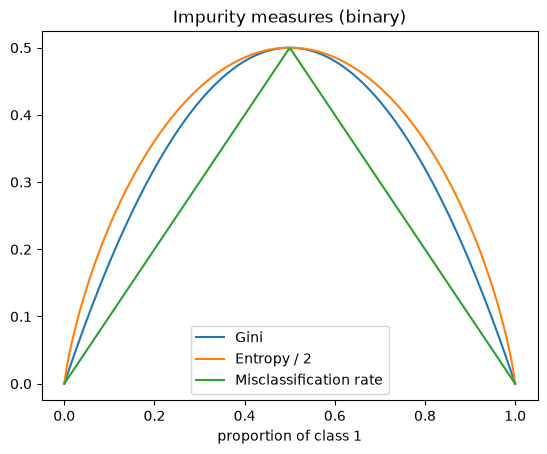

In [3]:
p = np.linspace(0, 1, 200)
plt.plot(p, 1 - p ** 2 - (1 - p) ** 2, label="Gini"); plt.plot(p, -(p * np.log2(p + 1e-12) + (1 - p) * np.log2(1 - p + 1e-12)) / 2, label="Entropy / 2")
plt.plot(p, 1 - np.maximum(p, 1 - p), label="Misclassification rate"); plt.xlabel("proportion of class 1"); plt.legend(); plt.title("Impurity measures (binary)"); plt.show()

## **3. CART From Scratch**

In [4]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature, self.threshold, self.left, self.right, self.value = feature, threshold, left, right, value

class TreeScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth, self.min_samples_split = max_depth, min_samples_split

    @staticmethod
    def gini(y):
        _, counts = np.unique(y, return_counts=True); p = counts / len(y); return 1 - np.sum(p ** 2)

    def best_split(self, X, y):
        best = (None, None, 0.0); parent = self.gini(y); n_ = len(y)
        for j in range(X.shape[1]):
            order = np.argsort(X[:, j]); xs, ys = X[order, j], y[order]
            for i in range(1, n_):
                if xs[i] == xs[i - 1]:
                    continue
                gain = parent - (i * self.gini(ys[:i]) + (n_ - i) * self.gini(ys[i:])) / n_
                if gain > best[2]:
                    best = (j, (xs[i] + xs[i - 1]) / 2, gain)
        return best

    def build(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return Node(value=pd.Series(y).mode()[0])
        j, t, gain = self.best_split(X, y)
        if j is None:
            return Node(value=pd.Series(y).mode()[0])
        m = X[:, j] <= t
        return Node(j, t, self.build(X[m], y[m], depth + 1), self.build(X[~m], y[~m], depth + 1))

    def fit(self, X, y):
        self.root_ = self.build(np.asarray(X, float), np.asarray(y), 0); return self

    def _predict_one(self, x, node):
        while node.value is None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.value

    def predict(self, X):
        return np.array([self._predict_one(x, self.root_) for x in np.asarray(X, float)])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
mine = TreeScratch(max_depth=4).fit(Xtr[:300], ytr[:300])
sk = DecisionTreeClassifier(max_depth=4, random_state=0).fit(Xtr[:300], ytr[:300])
print(f"scratch test acc {np.mean(mine.predict(Xte) == yte):.3f} | sklearn test acc {sk.score(Xte, yte):.3f}")
print(f"root split (scratch): {X.columns[mine.root_.feature]} <= {mine.root_.threshold:.3f}  | sklearn: {X.columns[sk.tree_.feature[0]]} <= {sk.tree_.threshold[0]:.3f}")

scratch test acc 0.919 | sklearn test acc 0.919
root split (scratch): ndwi <= 0.050  | sklearn: ndwi <= 0.050


## **4. Overfitting and Pruning**
A fully grown tree memorises the training data (one sample per leaf). Control it with:
- **Pre-pruning**: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_leaf_nodes`, `min_impurity_decrease`.
- **Post-pruning**: grow fully, then cut back with **cost-complexity pruning**: minimise $R(T) + \alpha|T|$ (error + alpha x number of leaves).

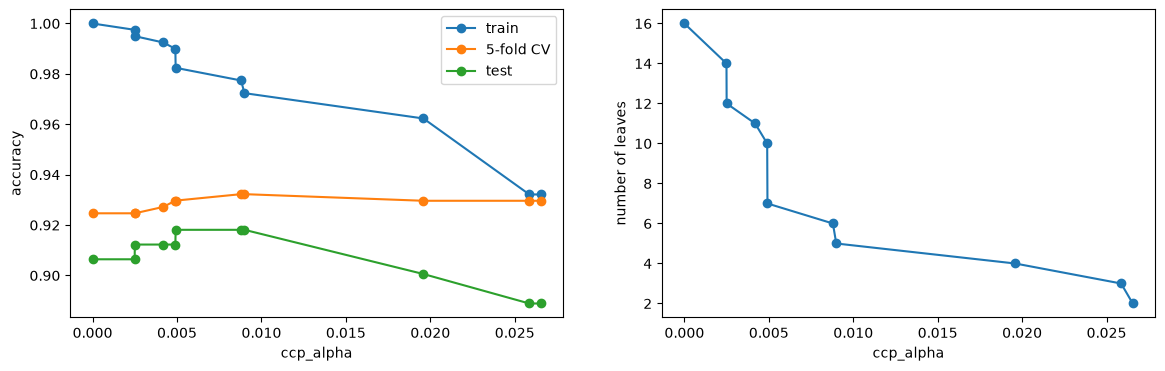

best alpha 0.0088: 6 leaves (unpruned: 16 leaves)


In [5]:
from sklearn.datasets import load_breast_cancer
Xb, yb = load_breast_cancer(return_X_y=True)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, random_state=0, stratify=yb)
path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(Xb_tr, yb_tr)
alphas = path.ccp_alphas[:-1]
trees = [DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(Xb_tr, yb_tr) for a in alphas]
cv = [cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a), Xb_tr, yb_tr, cv=5).mean() for a in alphas]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(alphas, [t.score(Xb_tr, yb_tr) for t in trees], "o-", label="train"); axes[0].plot(alphas, cv, "o-", label="5-fold CV")
axes[0].plot(alphas, [t.score(Xb_te, yb_te) for t in trees], "o-", label="test"); axes[0].set(xlabel="ccp_alpha", ylabel="accuracy"); axes[0].legend()
axes[1].plot(alphas, [t.get_n_leaves() for t in trees], "o-"); axes[1].set(xlabel="ccp_alpha", ylabel="number of leaves")
plt.show()
best_a = alphas[int(np.argmax(cv))]
print(f"best alpha {best_a:.4f}: {DecisionTreeClassifier(random_state=0, ccp_alpha=best_a).fit(Xb_tr, yb_tr).get_n_leaves()} leaves "
      f"(unpruned: {trees[0].get_n_leaves()} leaves)")

## **5. Regression Trees**
Leaves predict the **mean** target; the prediction is a step function.

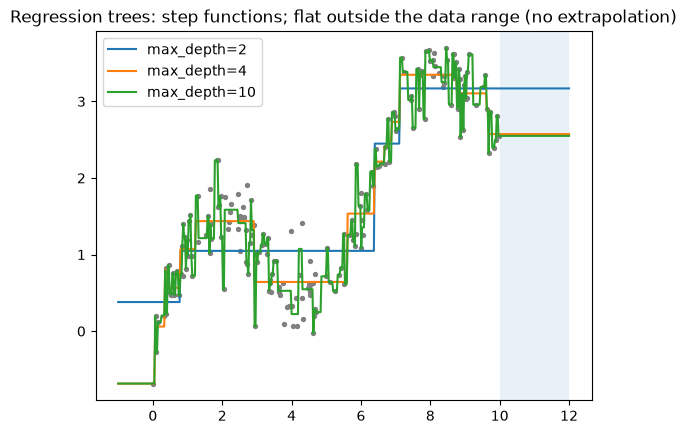

In [6]:
xr = np.sort(rng.uniform(0, 10, 200)); yr = np.sin(xr) + 0.3 * xr + rng.normal(0, 0.3, 200)
g = np.linspace(-1, 12, 500)[:, None]
plt.scatter(xr, yr, s=8, c="grey")
for d in [2, 4, 10]:
    plt.plot(g, DecisionTreeRegressor(max_depth=d).fit(xr[:, None], yr).predict(g), label=f"max_depth={d}")
plt.axvspan(10, 12, alpha=0.1); plt.legend(); plt.title("Regression trees: step functions; flat outside the data range (no extrapolation)"); plt.show()

**Trees cannot extrapolate**: beyond the training range they predict the last leaf's constant. Important for trends over time or for predicting in hotter/wetter conditions than observed.

## **6. Feature Importance**
**Impurity-based (MDI)** importance = total impurity reduction from splits on each feature. Fast, but **biased towards high-cardinality / continuous features** (more possible split points). Day 44 introduces unbiased **permutation importance**.

In [7]:
dfi = pd.DataFrame({"informative": rng.normal(size=1000), "random_continuous": rng.normal(size=1000),
                    "random_binary": rng.integers(0, 2, 1000), "random_id_like": rng.permutation(1000)})
yi = (dfi.informative + rng.normal(0, 1, 1000) > 0).astype(int)
deep = DecisionTreeClassifier(random_state=0).fit(dfi, yi)
from sklearn.inspection import permutation_importance
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(dfi, yi, random_state=0)
deep2 = DecisionTreeClassifier(min_samples_leaf=20, random_state=0).fit(Xi_tr, yi_tr)
print(pd.DataFrame({"MDI (fully grown tree)": deep.feature_importances_,
                    "permutation (test set)": permutation_importance(deep2, Xi_te, yi_te, n_repeats=20, random_state=0).importances_mean},
                   index=dfi.columns).round(3))

                   MDI (fully grown tree)  permutation (test set)
informative                         0.544                   0.183
random_continuous                   0.227                  -0.033
random_binary                       0.016                   0.000
random_id_like                      0.213                   0.001


# **Part 2: Going Deeper**

### Trees are unstable
Small changes in the data can change the root split and the whole tree (high variance). That is the motivation for **bagging** and **Random Forests** (Day 35-36), which average many trees.

In [8]:
roots = []
for b in range(20):
    i = rng.choice(len(Xb_tr), len(Xb_tr), replace=True)
    t = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xb_tr[i], yb_tr[i])
    roots.append(load_breast_cancer().feature_names[t.tree_.feature[0]])
print("Root-split feature over 20 bootstrap samples:\n", pd.Series(roots).value_counts())

Root-split feature over 20 bootstrap samples:
 worst perimeter         10
worst concave points     6
mean concave points      3
worst area               1
Name: count, dtype: int64


### Axis-aligned boundaries
Each split uses one feature, so boundaries are made of axis-parallel steps. A diagonal boundary needs many steps. Fixes: add a rotated/derived feature (e.g. a ratio or index, Day 19), oblique trees, or ensembles.

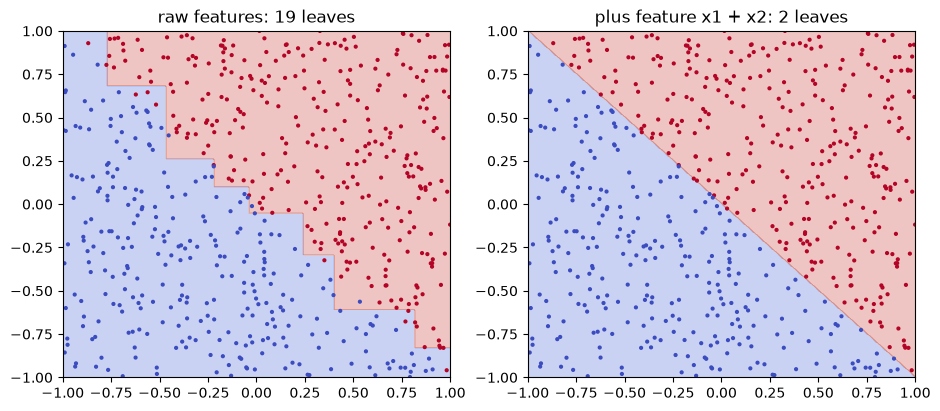

In [9]:
Xd = rng.uniform(-1, 1, (600, 2)); yd = (Xd[:, 0] + Xd[:, 1] > 0).astype(int)
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, Xf, f) in zip(axes, [("raw features", Xd, lambda G: G), ("plus feature x1 + x2", np.c_[Xd, Xd.sum(1)], lambda G: np.c_[G, G.sum(1)])]):
    t = DecisionTreeClassifier(min_samples_leaf=5).fit(Xf, yd)
    ax.contourf(xx, yy, t.predict(f(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape), alpha=0.3, cmap="coolwarm")
    ax.scatter(*Xd.T, c=yd, s=4, cmap="coolwarm"); ax.set_title(f"{name}: {t.get_n_leaves()} leaves")
plt.show()

## **Practice Problems**
1. Modify `TreeScratch` to use **entropy** instead of Gini. Do the root splits change?
2. Use `GridSearchCV` to tune `max_depth` and `min_samples_leaf` on the breast-cancer data.
3. Fit a regression tree to the `load_diabetes` data and plot CV R^2 vs `max_depth`.
4. *(Advanced)* Show that `predict_proba` of a tree with `min_samples_leaf=1` gives only 0/1 probabilities (overconfident). What does `min_samples_leaf=20` give?

entropy root: ndvi 0.298


{'max_depth': 3, 'min_samples_leaf': 5} 0.935 test 0.912


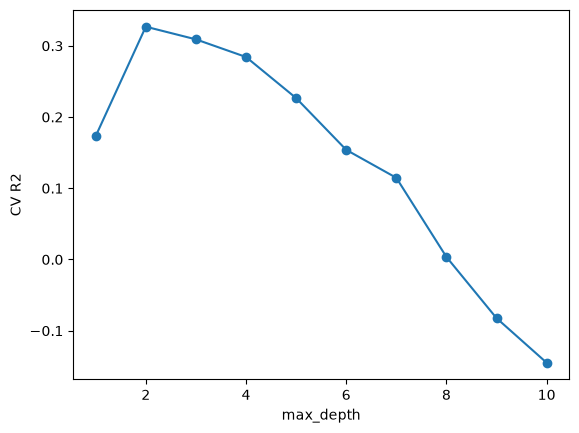

min_samples_leaf=1: distinct probability values = [0. 1.]
min_samples_leaf=20: distinct probability values = [0.    0.1   0.457 0.6   0.95  1.   ]


In [10]:
# Solution 1
class EntropyTree(TreeScratch):
    @staticmethod
    def gini(y):
        _, c = np.unique(y, return_counts=True); p_ = c / len(y); return -np.sum(p_ * np.log2(p_))
e = EntropyTree(max_depth=4).fit(Xtr[:300], ytr[:300])
print("entropy root:", X.columns[e.root_.feature], round(e.root_.threshold, 3))
# Solution 2
from sklearn.model_selection import GridSearchCV
g2 = GridSearchCV(DecisionTreeClassifier(random_state=0), {"max_depth": [2, 3, 4, 6, 8, None], "min_samples_leaf": [1, 5, 10, 20]}, cv=5).fit(Xb_tr, yb_tr)
print(g2.best_params_, round(g2.best_score_, 3), "test", round(g2.score(Xb_te, yb_te), 3))
# Solution 3
from sklearn.datasets import load_diabetes
Xdi, ydi = load_diabetes(return_X_y=True)
depths = range(1, 11)
plt.plot(depths, [cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=0), Xdi, ydi, cv=5).mean() for d in depths], "o-")
plt.xlabel("max_depth"); plt.ylabel("CV R2"); plt.show()
# Solution 4
for leaf in [1, 20]:
    pp = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=0).fit(Xb_tr, yb_tr).predict_proba(Xb_te)[:, 1]
    print(f"min_samples_leaf={leaf}: distinct probability values = {np.unique(pp.round(3))[:10]}")

## **Key References**
- Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth.
- Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning*, 1(1), 81-106.
- Quinlan, J. R. (1993). *C4.5: Programs for Machine Learning*. Morgan Kaufmann.
- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures. *BMC Bioinformatics*, 8, 25.
- Friedl, M. A., & Brodley, C. E. (1997). Decision tree classification of land cover from remotely sensed data. *Remote Sensing of Environment*, 61(3), 399-409.